# Evaluation of Feature Extraction Techniques in Content-Based Image Retrieval

## Foundations of Information Retrieval Project

### Group 23

## libraries preparetion

In [1]:
# Scikit-image library for image processing tools in python
%pip install scikit-image
# Scikit-learn library for ML in python
%pip install scikit-learn
# install the library h5py (needed to load and read the ground truth relevance file of assignment 02)
%pip install h5py
# install the library tqdm (for progress visualization)
%pip install tqdm
# Matplotlib/Pylab for plots and visualization in python
%pip install matplotlib
# openCV for image processing in python
%pip install opencv-python
%pip install opencv-contrib-python==3.4.17.63


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import json 
import time
from tqdm import tqdm
import cv2
from skimage.color import rgb2gray
from sklearn import preprocessing
import pickle
from scipy.spatial import distance
from sklearn.cluster import KMeans


## Load the query and map images with ground truth

In [12]:
# map
with open("data02/database/database.json","r") as f:
    m_idx = json.load(f)
    m_imgs = np.array(m_idx["im_paths"])
    m_loc=np.array(m_idx["loc"])

# query
with open("data02/query/query.json","r") as f:
    q_idx=json.load(f)
    q_imgs=np.array(q_idx["im_paths"])
    q_loc=np.array(q_idx["loc"])

# ground truth
with h5py.File("data02/london_gt.h5","r") as f:
    fovs = f["fov"][:]
    sim = f["sim"][:].astype(np.uint8)

## Visualization of image locations

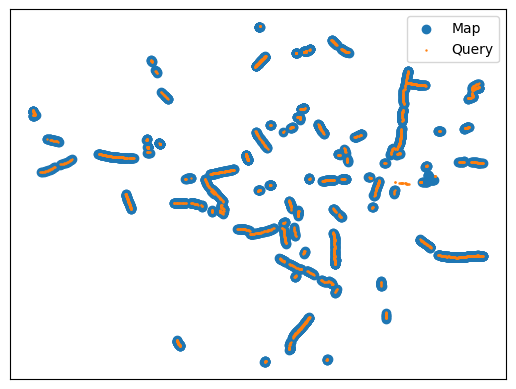

In [3]:
plt.scatter(m_loc[:,0],m_loc[:,1], label="Map")
plt.scatter(q_loc[:,0],q_loc[:,1], label="Query", s=0.5)
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

## Distribution of relevant images per query

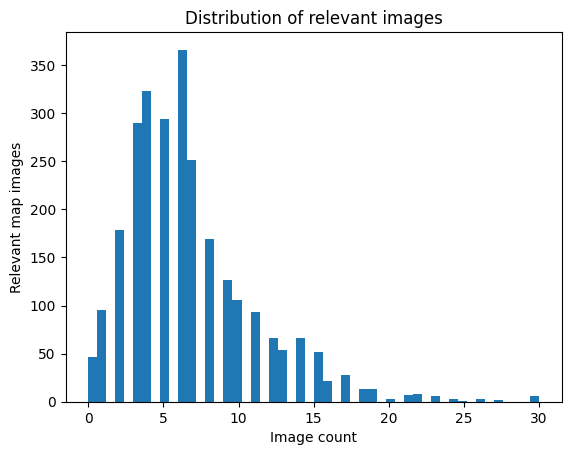

In [4]:
plt.hist(np.sum(sim, axis=1),bins=50)
plt.xlabel('Image count')
plt.ylabel('Relevant map images')
plt.title('Distribution of relevant images')
plt.show()

# Bag of Wordss
start with using different feature extractor like SIFT, AKAZE, ORB to detect and describe local features from the MSLS data images, partially re-used from assignment 2 (due to SURF is is now patented, it is not included in this project)

In [7]:
class FeatureExtractor:
    def __init__(self, descriptor_extractor, clustering_algorithm, scaler):
        # Initialize the desired feature extraction method, upper() is used to make the input case insensitive
        self.descriptor_extractor = descriptor_extractor
        # Initialize the desired clustering algorithm
        self.clustering_algorithm = clustering_algorithm
        # Initialize the data structure that will contain all the descriptors
        self.descriptors = None
        # Initialize an empty dictionary that will contain the centroids of the clusters
        self.centroids = {}
        # Initialize an empty dictionary that will contain the bag of words representation of the images
        self.bow_map_images = None
        self.scaler = scaler

        
    def get_descriptors(self, imgs):
        # Loop over map images
        for img_name in tqdm(imgs):
            img = cv2.imread(os.path.join('data02/', img_name))
            # Convert the image to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            keypoints, descriptors_img = self.descriptor_extractor.detectAndCompute(img, None)
            '''
            if type(self.descriptor_extractor) == cv2.xfeatures2d.BriefDescriptorExtractor_create:
                # Initiate FAST detector
                fast = cv2.FastFeatureDetector()
                # find the keypoints with FAST
                keypoints = fast.detect(img, None)
                # compute the descriptors with BRIEF
                keypoints, descriptors_img = self.descriptor_extractor.compute(img, keypoints)
            else:
                # Extract the keypoints and the descriptors
                keypoints, descriptors_img = self.descriptor_extractor.detectAndCompute(img, None)
            '''
            # Accumulate the computed descriptors
            self.descriptors = descriptors_img if self.descriptors is None else np.vstack((self.descriptors, descriptors_img))
        # print(self.descriptors.shape)
        # print(self.descriptors)

    def save_descriptors(self, filename: str):
        f = open('data02/project/'+ filename +'.bin', 'wb')
        data = pickle.dump(self.descriptors, f)
        f.close()

    def load_descriptors(self, filename: str):
        f = open('data02/project/'+ filename +'.bin', 'rb')
        self.descriptors = pickle.load(f)
        f.close()

    def cluster_features(self):
        clusters = self.clustering_algorithm.fit(self.descriptors)  # we use the descriptors extracted from the map (training) images before
        self.centroids = clusters.cluster_centers_

        print("Shape of the centroids matrix: ", self.centroids.shape)
        print("We computed ", self.centroids.shape[0], "centroids of lengh ", self.centroids.shape[1], " (the same of the descriptor)")
        # Rememeber: the centroids can be considered as the words that compose our documents 
        # -> in this case the basic components of the images are the descriptors, and the images are the documents
        
    def bag_of_words(self, img_descriptors):
        n_centroids = self.centroids.shape[0]  # number of centroids found with the KMeans clustering
        n_descriptors = img_descriptors.shape[0]  # number of descriptors extracted from the image
        
        # initialization of the bag of words (BoW) vector
        # Note that the BoW vector has length equal to the number of cluster centroids
        # The cluster centroids are indeed our visual words, and the BoW will be the histogram of these words found in the given image
        bow_vector = np.zeros(n_centroids)  
        
        for i in range(n_descriptors):
            # Compute distances between the current descriptor and all centroids
            distances = np.linalg.norm(self.centroids - img_descriptors[i], axis=1)
            
            # Find the closest centroid (i.e., the one with the minimum distance)
            closest_centroid_idx = np.argmin(distances)
            
            # Increment the count for the closest centroid in the BoW vector
            bow_vector[closest_centroid_idx] += 1
        return bow_vector
    
    def compute_bow(self, imgs):
        # Loop over map images
        for img_name in tqdm(imgs):
            img = cv2.imread(os.path.join('data02/', img_name))
            # Convert the image to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # Extract the keypoints and the descriptors
            keypoints, descriptors_img = self.descriptor_extractor.detectAndCompute(img, None)
            
            # compute BoW representation of the image (using the basic 'words', i.e. centroids, computed earlier)
            bow = self.bag_of_words(descriptors_img)
            # add the computed BoW vector to the set of map representations
            self.bow_map_images = bow if self.bow_map_images is None else np.vstack((self.bow_map_images, bow))
        # Compute z-score statistics
        self.scaler = self.scaler.fit(self.bow_map_images)
        # Normalize the vectors of the map collection (0 mean and 1 std)
        self.bow_map_images = self.scaler.transform(self.bow_map_images)

  

images retrieve

In [8]:
def get_query_bows(q_imgs, feature_extractor):
    query_bows = None

    for i in tqdm(range(len(q_imgs))):
        query_idx = i
        img = cv2.imread(os.path.join('data02/', q_imgs[query_idx]))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # Extract the keypoints and the descriptors
        __, query_img_descriptors = feature_extractor.descriptor_extractor.detectAndCompute(img, None)
        
        if query_img_descriptors is not None:
            query_bow = feature_extractor.bag_of_words(query_img_descriptors)
            # Normalize the query BoW vector using the mean and variance of the map (computed earlier and saved into the scaler object)
            query_bow = feature_extractor.scaler.transform(query_bow.reshape(1, -1))
            query_bow = query_bow.transpose().reshape(-1)            
        else:
            query_bow = np.zeros(feature_extractor.centroids.shape[0])
            print("No descriptors found for image ", q_imgs[query_idx])

        if query_bows is None:
            query_bows = query_bow
        else:
            query_bows = np.vstack( (query_bows, query_bow))
    return query_bows   


distance matrix

In [9]:
def retrieve_images(map_bow_vectors, query_bow, distance_metric):
    n_map_bow_vectors = map_bow_vectors.shape[0]
    bow_distances = np.zeros(n_map_bow_vectors)
    most_similar = None  # Initialize empty data structure to keep the ranking of the images
    
    for i in range(n_map_bow_vectors):
        if distance_metric == "euclidean":
            bow_distances[i] = distance.euclidean(query_bow,map_bow_vectors[i])
        elif distance_metric == "cosine":
            bow_distances[i] = distance.cosine(query_bow,map_bow_vectors[i])
        elif distance_metric == "minkowski":
            bow_distances[i] = distance.minkowski(query_bow,map_bow_vectors[i], p = 3)
        elif distance_metric == "manhattan":
            bow_distances[i] = distance.cityblock(query_bow,map_bow_vectors[i])
        elif distance_metric == "hamming":
            bow_distances[i] = distance.hamming(query_bow,map_bow_vectors[i])
        else:
            raise ValueError("Distance not recognized!")
    most_similar = np.argsort(bow_distances)
    
    return most_similar

evaluation matrix

In [10]:
def top_recall_at_k(query_bows, feature_extractor, distance_metric, k):
    count = 0
    for i in tqdm(range(len(query_bows))):
        query_idx = i

        retrieved = retrieve_images(feature_extractor.bow_map_images, query_bows[query_idx], distance_metric)
        relevant = np.where(sim[query_idx, :] == 1)[0]
        if len(set(retrieved[:k]).intersection(relevant)) > 0:
            count += 1
    return count / len(q_imgs)
        
def recall_at_k(relevant, retrieved, k):
    return len(set(retrieved[:k]).intersection(relevant)) / len(relevant)

def precision_at_k(relevant, retrieved, k):
    return len(set(retrieved[:k]).intersection(relevant)) / len(retrieved[:k])

def average_precision(relevant, retrieved):
    numerator = 0
    for i in range(len(retrieved)):
        if retrieved[i] in relevant:
            numerator += precision_at_k(relevant, retrieved, i+1)
    return numerator/len(relevant)

def average_precision(relevant, retrieved):
    numerator = 0
    for i in range(len(retrieved)):
        if retrieved[i] in relevant:
            numerator += precision_at_k(relevant, retrieved, i+1)
    if len(relevant) == 0:
        return 1
    else:
        return numerator/len(relevant)

def mean_average_precision(query_bows, feature_extractor, distance_metric):
    count = 0
    for i in tqdm(range(len(q_imgs))):
        query_idx = i
    
        retrieved_images = retrieve_images(feature_extractor.bow_map_images, query_bows[query_idx], distance_metric)
        relevant_images = np.where(sim[query_idx, :] == 1)[0]
        avg_prec = average_precision(relevant_images, retrieved_images)

        count += avg_prec

    mean_avg_prec = count / len(q_imgs)
    return mean_avg_prec


# SIFT

## 50 keypoints/number of features

### Setups

In [10]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.SIFT_create(nfeatures=50)

In [11]:
sift50 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [12]:
sift50.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [02:27<00:00, 22.37it/s]


In [13]:
sift50.descriptors.shape

(165311, 128)

In [14]:
sift50.save_descriptors('sift50')

In [15]:
sift50.load_descriptors('sift50')

In [16]:
sift50.cluster_features()

e:\A\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\A\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Initialization complete
Iteration 0, inertia 22331963392.0.
Iteration 1, inertia 14694524928.0.
Iteration 2, inertia 14400265216.0.
Iteration 3, inertia 14275766272.0.
Iteration 4, inertia 14199964672.0.
Iteration 5, inertia 14144714752.0.
Iteration 6, inertia 14098403328.0.
Iteration 7, inertia 14059805696.0.
Iteration 8, inertia 14030045184.0.
Iteration 9, inertia 14006146048.0.
Iteration 10, inertia 13988123648.0.
Iteration 11, inertia 13976269824.0.
Iteration 12, inertia 13968936960.0.
Iteration 13, inertia 13963797504.0.
Iteration 14, inertia 13960168448.0.
Iteration 15, inertia 13957135360.0.
Iteration 16, inertia 13954572288.0.
Iteration 17, inertia 13952516096.0.
Iteration 18, inertia 13950751744.0.
Iteration 19, inertia 13949196288.0.
Iteration 20, inertia 13947702272.0.
Iteration 21, inertia 13946081280.0.
Iteration 22, inertia 13944395776.0.
Iteration 23, inertia 13942776832.0.
Iteration 24, inertia 13940975616.0.
Iteration 25, inertia 13939101696.0.
Iteration 26, inertia 13

In [17]:
sift50.centroids.shape  # check the shape of the centroids matrix

(32, 128)

In [18]:
sift50.compute_bow(m_imgs)

100%|██████████| 3291/3291 [02:00<00:00, 27.39it/s]


In [19]:
sift50.bow_map_images

array([[ 0.13003194, -0.49598412, -0.46777674, ...,  1.36360463,
         0.86275359, -0.38553228],
       [-0.65229915, -0.49598412, -0.46777674, ...,  0.1516071 ,
        -1.14147374, -0.38553228],
       [-0.65229915, -0.49598412,  0.21279499, ...,  0.1516071 ,
        -0.47339797,  0.2013256 ],
       ...,
       [-0.65229915, -0.49598412,  0.89336672, ..., -0.65639125,
        -0.47339797,  0.78818348],
       [-0.2611336 ,  0.17935049, -1.14834847, ..., -0.65639125,
         0.86275359,  1.37504136],
       [-0.2611336 , -1.17131873, -0.46777674, ...,  0.1516071 ,
        -0.47339797, -0.38553228]])

### Retrieving images

In [20]:
query_bows = get_query_bows(q_imgs, sift50)
query_bows.shape

100%|██████████| 2692/2692 [01:37<00:00, 27.59it/s]


(2692, 32)

In [21]:
query_bows

array([[ 0.52119748, -1.17131873, -0.46777674, ..., -0.25239207,
        -1.14147374,  1.37504136],
       [ 0.13003194, -0.49598412,  2.25451017, ..., -0.65639125,
         1.53082936, -0.97239016],
       [ 1.30352856, -1.17131873, -1.14834847, ...,  0.1516071 ,
        -1.14147374, -0.38553228],
       ...,
       [ 0.52119748,  0.8546851 , -0.46777674, ...,  1.76760381,
        -0.47339797, -0.97239016],
       [-0.65229915, -0.49598412, -0.46777674, ...,  1.76760381,
        -1.14147374, -0.97239016],
       [-0.2611336 , -0.49598412, -0.46777674, ..., -0.25239207,
        -0.47339797,  0.2013256 ]])

### Evaluation

In [22]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, sift50, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, sift50, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, sift50, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, sift50, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [00:53<00:00, 50.35it/s]


Top recall at 1:  0.009286775631500743


100%|██████████| 2692/2692 [01:08<00:00, 39.51it/s]


Top recall at 5:  0.034546805349182766


...

Top recall at 5:  0.02823179791976226


100%|██████████| 2692/2692 [01:48<00:00, 24.74it/s]


Top recall at 10:  0.050148588410104014


100%|██████████| 2692/2692 [02:37<00:00, 17.12it/s]

Mean average precision (hamming distance):  0.025421057960050154


## 100 keypoints/number of features

### Setups

In [23]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.SIFT_create(nfeatures=100)

In [24]:
sift100 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [25]:
sift100.get_descriptors(m_imgs)

  1%|          | 19/3291 [00:00<01:55, 28.33it/s]

100%|██████████| 3291/3291 [03:16<00:00, 16.72it/s]


In [26]:
sift100.descriptors.shape

(329731, 128)

In [27]:
sift100.save_descriptors('sift100')

In [28]:
sift100.load_descriptors('sift100')

In [29]:
sift100.cluster_features()

Initialization complete
Iteration 0, inertia 45125529600.0.
Iteration 1, inertia 29868683264.0.
Iteration 2, inertia 29376133120.0.
Iteration 3, inertia 29179426816.0.
Iteration 4, inertia 29072349184.0.
Iteration 5, inertia 29007593472.0.
Iteration 6, inertia 28962144256.0.
Iteration 7, inertia 28926609408.0.
Iteration 8, inertia 28896460800.0.
Iteration 9, inertia 28868446208.0.
Iteration 10, inertia 28842833920.0.
Iteration 11, inertia 28819621888.0.
Iteration 12, inertia 28797194240.0.
Iteration 13, inertia 28776230912.0.
Iteration 14, inertia 28756951040.0.
Iteration 15, inertia 28740622336.0.
Iteration 16, inertia 28727064576.0.
Iteration 17, inertia 28716161024.0.
Iteration 18, inertia 28707205120.0.
Iteration 19, inertia 28699631616.0.
Iteration 20, inertia 28693319680.0.
Iteration 21, inertia 28687994880.0.
Iteration 22, inertia 28683509760.0.
Iteration 23, inertia 28679626752.0.
Iteration 24, inertia 28676501504.0.
Iteration 25, inertia 28673789952.0.
Iteration 26, inertia 28

In [30]:
sift100.centroids.shape

(32, 128)

In [31]:
sift100.compute_bow(m_imgs)

100%|██████████| 3291/3291 [02:01<00:00, 27.04it/s]


### Retrieving images

In [32]:
query_bows = get_query_bows(q_imgs, sift100)
query_bows.shape

100%|██████████| 2692/2692 [01:20<00:00, 33.62it/s]


(2692, 32)

### Evaluation

In [33]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, sift100, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, sift100, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, sift100, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, sift100, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [01:09<00:00, 38.89it/s]


Top recall at 1:  0.017830609212481426


100%|██████████| 2692/2692 [01:01<00:00, 43.68it/s]


Top recall at 5:  0.04977711738484398


...

Top recall at 5:  0.02674591381872214


100%|██████████| 2692/2692 [01:49<00:00, 24.54it/s]


Top recall at 10:  0.05163447251114413


100%|██████████| 2692/2692 [02:34<00:00, 17.40it/s]

Mean average precision (hamming distance):  0.02522954107363325


## 200 keypoints/number of features

### Setups

In [34]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.SIFT_create(nfeatures=200)

In [35]:
sift200 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [36]:
sift200.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [04:56<00:00, 11.12it/s]


In [37]:
sift200.descriptors.shape

(656521, 128)

In [38]:
sift200.save_descriptors('sift200')

In [39]:
sift200.load_descriptors('sift200')

In [40]:
sift200.cluster_features()

Initialization complete
Iteration 0, inertia 93887127552.0.
Iteration 1, inertia 61808603136.0.
Iteration 2, inertia 60571938816.0.
Iteration 3, inertia 59897585664.0.
Iteration 4, inertia 59453939712.0.
Iteration 5, inertia 59223674880.0.
Iteration 6, inertia 59094003712.0.
Iteration 7, inertia 59013423104.0.
Iteration 8, inertia 58956750848.0.
Iteration 9, inertia 58911248384.0.
Iteration 10, inertia 58872356864.0.
Iteration 11, inertia 58836926464.0.
Iteration 12, inertia 58803986432.0.
Iteration 13, inertia 58773839872.0.
Iteration 14, inertia 58747740160.0.
Iteration 15, inertia 58725519360.0.
Iteration 16, inertia 58707050496.0.
Iteration 17, inertia 58691502080.0.
Iteration 18, inertia 58678951936.0.
Iteration 19, inertia 58668163072.0.
Iteration 20, inertia 58658230272.0.
Iteration 21, inertia 58647764992.0.
Iteration 22, inertia 58635329536.0.
Iteration 23, inertia 58622586880.0.
Iteration 24, inertia 58612256768.0.
Iteration 25, inertia 58604449792.0.
Iteration 26, inertia 58

In [41]:
sift200.centroids.shape

(32, 128)

In [42]:
sift200.compute_bow(m_imgs)

100%|██████████| 3291/3291 [02:13<00:00, 24.67it/s]


### Retrieving images

In [43]:
query_bows = get_query_bows(q_imgs, sift200)
query_bows.shape

100%|██████████| 2692/2692 [01:54<00:00, 23.42it/s]


(2692, 32)

### Evaluation

In [44]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, sift200, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, sift200, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, sift200, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, sift200, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [01:03<00:00, 42.22it/s]


Top recall at 1:  0.023402674591381872


100%|██████████| 2692/2692 [01:12<00:00, 36.98it/s]


Top recall at 5:  0.06537890044576523


...

Top recall at 5:  0.022659732540861812


100%|██████████| 2692/2692 [01:44<00:00, 25.66it/s]


Top recall at 10:  0.04606240713224369


100%|██████████| 2692/2692 [02:34<00:00, 17.43it/s]

Mean average precision (hamming distance):  0.024333782597342618


# AKAZE

## Threshold = 0.001

In [45]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.AKAZE_create(threshold=0.001)    # Lower th -> more features; Higher -> fewer features

In [46]:
akaze1 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [47]:
akaze1.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [01:54<00:00, 28.72it/s]


In [48]:
akaze1.descriptors.shape

(788122, 61)

In [49]:
akaze1.save_descriptors('akaze1')

In [50]:
akaze1.load_descriptors('akaze1')

In [51]:
akaze1.cluster_features()

Initialization complete
Iteration 0, inertia 390045686301.0.
Iteration 1, inertia 268544847097.8709.
Iteration 2, inertia 263523561316.70175.
Iteration 3, inertia 261468991759.73148.
Iteration 4, inertia 260271263840.8679.
Iteration 5, inertia 259497489989.09628.
Iteration 6, inertia 258974936276.2752.
Iteration 7, inertia 258618076479.2339.
Iteration 8, inertia 258369045273.6553.
Iteration 9, inertia 258181621964.5935.
Iteration 10, inertia 258037779122.99466.
Iteration 11, inertia 257922766218.25775.
Iteration 12, inertia 257826610438.7127.
Iteration 13, inertia 257743372584.09818.
Iteration 14, inertia 257669712888.47894.
Iteration 15, inertia 257602953915.16425.
Iteration 16, inertia 257541388949.4348.
Iteration 17, inertia 257485471956.4732.
Iteration 18, inertia 257435829267.1414.
Iteration 19, inertia 257388727151.21436.
Iteration 20, inertia 257344563546.19177.
Iteration 21, inertia 257304679939.01218.
Iteration 22, inertia 257268799187.9075.
Iteration 23, inertia 257234631778.

In [52]:
akaze1.centroids.shape

(32, 61)

In [53]:
akaze1.compute_bow(m_imgs)

100%|██████████| 3291/3291 [01:33<00:00, 35.25it/s]


In [54]:
akaze1.bow_map_images

array([[-0.47336058, -0.28199554, -0.7473087 , ..., -0.85736154,
        -0.12304573, -0.04078317],
       [-0.47336058, -0.28199554,  0.13432054, ...,  0.82065026,
         0.65794464,  0.1622689 ],
       [-0.47336058, -0.47513755, -0.57098285, ...,  1.65965616,
         0.65794464, -0.6499394 ],
       ...,
       [ 2.95309876,  3.96712855,  2.60288243, ...,  3.7571709 ,
         1.82943021,  1.17752928],
       [ 1.13909088,  3.00141853,  3.13185998, ...,  2.28891058,
         2.2199254 , -0.04078317],
       [ 0.33286515, -0.08885354,  0.13432054, ..., -0.85736154,
         2.61042059, -0.6499394 ]])

### Retrieving Images

In [55]:
query_bows = get_query_bows(q_imgs, akaze1)
query_bows.shape

100%|██████████| 2692/2692 [01:21<00:00, 32.94it/s]


(2692, 32)

In [56]:
query_bows

array([[-1.2795863 , -0.66827955, -1.27628625, ..., -1.06711302,
        -0.90403611,  1.17752928],
       [-1.07802987, -0.66827955, -0.7473087 , ..., -1.06711302,
         0.26744946, -0.85299147],
       [-0.47336058, -0.08885354, -1.4526121 , ..., -1.27686449,
         0.07220186, -1.25909563],
       ...,
       [-0.67491701, -0.86142155, -1.27628625, ..., -0.85736154,
        -1.09928371, -0.6499394 ],
       [-1.2795863 , -1.05456356, -1.27628625, ..., -1.06711302,
        -1.68502649, -1.05604355],
       [-0.87647344, -0.47513755, -1.0999604 , ..., -1.06711302,
        -1.4897789 , -1.05604355]])

### Evaluation

In [57]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, akaze1, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, akaze1, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, akaze1, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, akaze1, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [01:05<00:00, 41.22it/s]


Top recall at 1:  0.015230312035661218


100%|██████████| 2692/2692 [00:56<00:00, 48.04it/s]


Top recall at 5:  0.04457652303120357


...

Top recall at 5:  0.018945022288261514


100%|██████████| 2692/2692 [02:01<00:00, 22.11it/s]


Top recall at 10:  0.03417533432392273


100%|██████████| 2692/2692 [02:47<00:00, 16.04it/s]

Mean average precision (hamming distance):  0.02331121305575773


### Threshold 0.002

In [58]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.AKAZE_create(threshold=0.002)

In [59]:
akaze2 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [60]:
akaze2.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [01:53<00:00, 29.00it/s]


In [61]:
akaze2.descriptors.shape

(460032, 61)

In [62]:
akaze2.save_descriptors('akaze2')

In [63]:
akaze2.load_descriptors('akaze2')

In [64]:
akaze2.cluster_features()

Initialization complete
Iteration 0, inertia 226743705242.0.
Iteration 1, inertia 155217105114.9521.
Iteration 2, inertia 152269709330.04172.
Iteration 3, inertia 151164351275.00482.
Iteration 4, inertia 150576743246.3021.
Iteration 5, inertia 150202979179.44278.
Iteration 6, inertia 149945107405.53378.
Iteration 7, inertia 149759220831.9055.
Iteration 8, inertia 149622003944.82678.
Iteration 9, inertia 149519101465.2483.
Iteration 10, inertia 149438837553.53992.
Iteration 11, inertia 149371378154.21832.
Iteration 12, inertia 149314457174.6058.
Iteration 13, inertia 149263707707.92603.
Iteration 14, inertia 149218509354.3682.
Iteration 15, inertia 149177198912.86905.
Iteration 16, inertia 149138818886.2034.
Iteration 17, inertia 149102989445.1042.
Iteration 18, inertia 149069222886.31525.
Iteration 19, inertia 149037391983.1422.
Iteration 20, inertia 149007445131.59647.
Iteration 21, inertia 148979744486.5556.
Iteration 22, inertia 148955175932.45294.
Iteration 23, inertia 148933074046

In [65]:
akaze2.centroids.shape

(32, 61)

In [66]:
akaze2.compute_bow(m_imgs)

100%|██████████| 3291/3291 [01:51<00:00, 29.40it/s]


### Retrieving images

In [67]:
query_bows = get_query_bows(q_imgs, akaze2)

 94%|█████████▍| 2539/2692 [01:39<00:04, 35.82it/s]

No descriptors found for image  query/images/Zg46XqkNGjeZrAamZ-bYJw.jpg
No descriptors found for image  query/images/me5EuwAWswFuCelNyfnoQA.jpg


 95%|█████████▌| 2570/2692 [01:40<00:03, 38.39it/s]

No descriptors found for image  query/images/6ZSqefbehcVgKTm1lL7WEA.jpg


100%|██████████| 2692/2692 [01:44<00:00, 25.83it/s]


In [68]:
query_bows.shape

(2692, 32)

### Evaluation

In [69]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, akaze2, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, akaze2, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, akaze2, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, akaze2, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [01:09<00:00, 38.82it/s]


Top recall at 1:  0.01263001485884101


100%|██████████| 2692/2692 [01:11<00:00, 37.59it/s]


Top recall at 5:  0.04011887072808321


...

Top recall at 5:  0.018202080237741457


100%|██████████| 2692/2692 [01:40<00:00, 26.75it/s]


Top recall at 10:  0.036404160475482915


100%|██████████| 2692/2692 [02:09<00:00, 20.76it/s]

Mean average precision (hamming distance):  0.023942605357370438


# ORB

## 50 keypoints/number of features

### setups

In [70]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.ORB_create(nfeatures=50)

In [71]:
orb50 = FeatureExtractor(descriptor_extractor = descriptor_extractor, clustering_algorithm = kmeans, scaler=stdscaler)

In [72]:
orb50.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [00:39<00:00, 82.98it/s]


In [73]:
orb50.descriptors.shape

(163295, 32)

In [74]:
orb50.save_descriptors("orb50-descriptors")

In [75]:
orb50.load_descriptors("orb50-descriptors")

In [76]:
orb50.cluster_features()

Initialization complete
Iteration 0, inertia 27300848067.0.
Iteration 1, inertia 19762404916.828197.
Iteration 2, inertia 19258225339.981075.
Iteration 3, inertia 19065920950.32685.
Iteration 4, inertia 18968054016.923412.
Iteration 5, inertia 18907527410.237812.
Iteration 6, inertia 18864830959.26498.
Iteration 7, inertia 18833862670.956356.
Iteration 8, inertia 18811011629.347054.
Iteration 9, inertia 18793250613.289696.
Iteration 10, inertia 18778997322.50755.
Iteration 11, inertia 18767773679.396294.
Iteration 12, inertia 18758669382.30345.
Iteration 13, inertia 18750915446.2894.
Iteration 14, inertia 18744462486.711933.
Iteration 15, inertia 18738980197.883118.
Iteration 16, inertia 18734304620.799664.
Iteration 17, inertia 18730264528.594437.
Iteration 18, inertia 18726642772.62718.
Iteration 19, inertia 18723588456.44542.
Iteration 20, inertia 18720680754.314938.
Iteration 21, inertia 18717884113.451153.
Iteration 22, inertia 18715374185.644928.
Iteration 23, inertia 18713165216

In [77]:
orb50.centroids.shape

(32, 32)

In [78]:
orb50.compute_bow(m_imgs)

100%|██████████| 3291/3291 [00:19<00:00, 166.85it/s]


### Retrieving images

In [79]:
query_bows = get_query_bows(q_imgs, orb50)


100%|██████████| 2692/2692 [00:38<00:00, 69.89it/s]


In [80]:
query_bows.shape

(2692, 32)

### Evaluation

In [81]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, orb50, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, orb50, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, orb50, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, orb50, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [00:53<00:00, 50.68it/s]


Top recall at 1:  0.007429420505200594


100%|██████████| 2692/2692 [00:56<00:00, 47.99it/s]


Top recall at 5:  0.022659732540861812


...

Top recall at 5:  0.018202080237741457


100%|██████████| 2692/2692 [01:15<00:00, 35.55it/s]


Top recall at 10:  0.03900445765230312


100%|██████████| 2692/2692 [01:49<00:00, 24.54it/s]

Mean average precision (hamming distance):  0.023231537293327102


## 100 keypoints

In [82]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.ORB_create(nfeatures=100)

In [83]:
orb100 = FeatureExtractor(descriptor_extractor=descriptor_extractor, clustering_algorithm = kmeans, scaler = stdscaler)

In [84]:
orb100.get_descriptors(m_imgs)
orb100.descriptors.shape

100%|██████████| 3291/3291 [00:18<00:00, 175.59it/s]


(324397, 32)

In [85]:
orb100.save_descriptors("orb100-descriptors")

In [86]:
orb100.load_descriptors("orb100-descriptors")

In [87]:
orb100.cluster_features()

Initialization complete
Iteration 0, inertia 54670637580.0.
Iteration 1, inertia 38852277685.159676.
Iteration 2, inertia 38098672829.95167.
Iteration 3, inertia 37861120661.643845.
Iteration 4, inertia 37741050061.84555.
Iteration 5, inertia 37662317626.40293.
Iteration 6, inertia 37606499393.86174.
Iteration 7, inertia 37564472562.3442.
Iteration 8, inertia 37532533731.1294.
Iteration 9, inertia 37507943148.207825.
Iteration 10, inertia 37487719256.086266.
Iteration 11, inertia 37470169648.70682.
Iteration 12, inertia 37454912077.95505.
Iteration 13, inertia 37441307900.99797.
Iteration 14, inertia 37429374673.76604.
Iteration 15, inertia 37418733815.72951.
Iteration 16, inertia 37409039496.68109.
Iteration 17, inertia 37400622656.784904.
Iteration 18, inertia 37393047076.95099.
Iteration 19, inertia 37386248115.098816.
Iteration 20, inertia 37379998063.48983.
Iteration 21, inertia 37373870170.0839.
Iteration 22, inertia 37367777160.68763.


Iteration 23, inertia 37361654362.05028.
Iteration 24, inertia 37355377115.5901.
Iteration 25, inertia 37349040825.54931.
Iteration 26, inertia 37343035918.394356.
Iteration 27, inertia 37337599301.151344.
Iteration 28, inertia 37332719217.42693.
Iteration 29, inertia 37327856697.0121.
Iteration 30, inertia 37323218491.70694.
Iteration 31, inertia 37319129027.299835.
Iteration 32, inertia 37315551336.22337.
Iteration 33, inertia 37312414203.72894.
Iteration 34, inertia 37309441850.01977.
Iteration 35, inertia 37306527709.548386.
Iteration 36, inertia 37303872241.373344.
Iteration 37, inertia 37301413955.515175.
Iteration 38, inertia 37299177146.04167.
Iteration 39, inertia 37297065456.64761.
Iteration 40, inertia 37295184806.30211.
Iteration 41, inertia 37293486968.506294.
Iteration 42, inertia 37291931914.147896.
Iteration 43, inertia 37290450485.67506.
Iteration 44, inertia 37288974491.12188.
Iteration 45, inertia 37287586743.49984.
Iteration 46, inertia 37286203563.49795.
Iteration 

In [88]:
orb100.centroids.shape

(32, 32)

In [89]:
orb100.compute_bow(m_imgs)

100%|██████████| 3291/3291 [00:14<00:00, 229.40it/s]


### Retrieving images

In [90]:
query_bows = get_query_bows(q_imgs, orb100)
query_bows.shape

100%|██████████| 2692/2692 [00:11<00:00, 228.28it/s]


(2692, 32)

### Evaluation

In [91]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, orb100, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, orb100, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, orb100, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, orb100, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [00:47<00:00, 56.76it/s]


Top recall at 1:  0.006686478454680535


100%|██████████| 2692/2692 [00:55<00:00, 48.61it/s]


Top recall at 5:  0.02786032689450223


...

Top recall at 5:  0.017830609212481426


100%|██████████| 2692/2692 [01:28<00:00, 30.38it/s]


Top recall at 10:  0.030832095096582468


100%|██████████| 2692/2692 [01:37<00:00, 27.74it/s]

Mean average precision (hamming distance):  0.023010200145417742


## 200 features

In [92]:
K = 32  # number of clusters (equivalent to the number of words) we want to estimate
num_initialization = 5 # Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of num_initialization consecutive runs in terms of inertia.
# Run the k-means clustering
kmeans = KMeans(n_clusters=K, random_state=0, n_init=num_initialization, max_iter = 500, verbose=1)

stdscaler = preprocessing.StandardScaler()

descriptor_extractor = cv2.ORB_create(nfeatures=200)

In [93]:
orb200 = FeatureExtractor(descriptor_extractor=descriptor_extractor, clustering_algorithm = kmeans, scaler = stdscaler)

In [94]:
orb200.get_descriptors(m_imgs)

100%|██████████| 3291/3291 [00:18<00:00, 173.39it/s]


In [95]:
orb200.save_descriptors("orb200-descriptors")

In [96]:
orb200.load_descriptors("orb200-descriptors")

In [97]:
orb200.cluster_features()

Initialization complete
Iteration 0, inertia 106950882710.0.
Iteration 1, inertia 76874727974.69296.
Iteration 2, inertia 75215856267.87828.
Iteration 3, inertia 74628459550.7085.
Iteration 4, inertia 74343827547.4615.
Iteration 5, inertia 74176572331.42169.
Iteration 6, inertia 74067019277.55434.
Iteration 7, inertia 73990529690.12822.
Iteration 8, inertia 73933638760.468.
Iteration 9, inertia 73887537309.02902.
Iteration 10, inertia 73847912686.68362.
Iteration 11, inertia 73811920235.48213.
Iteration 12, inertia 73778514312.20811.
Iteration 13, inertia 73746619036.35396.
Iteration 14, inertia 73716046129.14095.
Iteration 15, inertia 73686666844.33472.
Iteration 16, inertia 73657635242.93918.
Iteration 17, inertia 73629178347.97836.
Iteration 18, inertia 73601413778.33725.
Iteration 19, inertia 73574975190.50465.
Iteration 20, inertia 73550797365.94371.
Iteration 21, inertia 73528645624.0805.
Iteration 22, inertia 73507965292.7706.
Iteration 23, inertia 73489143165.02718.
Iteration 2

In [98]:
orb200.centroids.shape 

(32, 32)

In [99]:
orb200.compute_bow(m_imgs)

100%|██████████| 3291/3291 [00:23<00:00, 141.60it/s]


### Rertrieving images

In [100]:
query_bows = get_query_bows(q_imgs, orb200)
query_bows.shape

100%|██████████| 2692/2692 [00:17<00:00, 156.60it/s]


(2692, 32)

### Evaluation

In [101]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_bows, orb200, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_bows, orb200, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_bows, orb200, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_bows, orb200, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [00:42<00:00, 63.48it/s]


Top recall at 1:  0.007429420505200594


100%|██████████| 2692/2692 [00:40<00:00, 66.54it/s]


Top recall at 5:  0.031575037147102525


...

Top recall at 5:  0.017087667161961365


100%|██████████| 2692/2692 [01:25<00:00, 31.33it/s]


Top recall at 10:  0.028603268945022287


100%|██████████| 2692/2692 [01:37<00:00, 27.47it/s]

Mean average precision (hamming distance):  0.022911969270293073


# VGG16

In [2]:
import keras
from keras.utils import load_img, img_to_array 
from keras.applications.imagenet_utils import decode_predictions, preprocess_input
from keras.models import Model

In [3]:
model = keras.applications.vgg16.VGG16(weights='imagenet', include_top=True)
model.summary()

553467096/553467096 [==============================] - 61s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                           

In [4]:
def load_image(path):
    img = load_img(path, target_size=model.input_shape[1:3]) # load the image and resize it.
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

In [5]:
feat_extractor = Model(inputs=model.input, outputs=model.get_layer("fc2").output)
feat_extractor.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [13]:
db_imgs = [os.path.join('./data02/', img_name) for img_name in m_imgs]
query_imgs = [os.path.join('./data02/', img_name) for img_name in q_imgs]

In [15]:
tic = time.time()
query_features = []
for i, image_path in enumerate(query_imgs):
    if i % 500 == 0:
        toc = time.time()
        elap = toc-tic
        print("analyzing image %d / %d. Time: %4.4f seconds." % (i, len(query_imgs),elap))
        tic = time.time()
    img, x = load_image(image_path)
    feat = feat_extractor.predict(x, verbose = 0)[0]
    query_features.append(feat)
query_features = np.array(query_features)

print('finished extracting features for %d images' % len(query_imgs))

analyzing image 0 / 2692. Time: 0.0000 seconds.
analyzing image 500 / 2692. Time: 191.9666 seconds.
analyzing image 1000 / 2692. Time: 232.4275 seconds.
analyzing image 1500 / 2692. Time: 270.7661 seconds.
analyzing image 2000 / 2692. Time: 249.6796 seconds.
analyzing image 2500 / 2692. Time: 223.9877 seconds.
finished extracting features for 2692 images


In [16]:
tic = time.time()
database_features = []
for i, image_path in enumerate(db_imgs):
    if i % 500 == 0:
        toc = time.time()
        elap = toc-tic
        print("analyzing image %d / %d. Time: %4.4f seconds." % (i, len(db_imgs),elap))
        tic = time.time()
    img, x = load_image(image_path)
    feat = feat_extractor.predict(x, verbose = 0)[0]
    database_features.append(feat)

print('finished extracting features for %d images' % len(db_imgs))

analyzing image 0 / 3291. Time: 0.0000 seconds.
analyzing image 500 / 3291. Time: 228.6555 seconds.
analyzing image 1000 / 3291. Time: 293.7511 seconds.
analyzing image 1500 / 3291. Time: 359.1820 seconds.
analyzing image 2000 / 3291. Time: 345.3803 seconds.
analyzing image 2500 / 3291. Time: 424.6452 seconds.
analyzing image 3000 / 3291. Time: 386.1028 seconds.
finished extracting features for 3291 images


In [18]:
vgg16 = FeatureExtractor(descriptor_extractor=None, clustering_algorithm =None, scaler =None) # we don't need these parameters for the VGG16 features only for calculating the evaluation metrics

vgg16.bow_map_images = np.array(database_features)

In [28]:
distance_metrics = ["euclidean", "cosine", "minkowski", "manhattan", "hamming"]

for metric in distance_metrics:
    print(f"Computing results for {metric} distance")
    print("Top recall at 1: ", top_recall_at_k(query_features, vgg16, metric, 1))
    print("Top recall at 5: ", top_recall_at_k(query_features, vgg16, metric, 5))
    print("Top recall at 10: ", top_recall_at_k(query_features, vgg16, metric, 10))
    print(f"Mean average precision ({metric} distance): ", mean_average_precision(query_features, vgg16, metric))

Computing results for euclidean distance


100%|██████████| 2692/2692 [01:29<00:00, 30.15it/s]


Top recall at 1:  0.12295690936106983


100%|██████████| 2692/2692 [01:29<00:00, 29.99it/s]


Top recall at 5:  0.2511144130757801


...

Top recall at 5:  0.09472511144130757


100%|██████████| 2692/2692 [03:52<00:00, 11.58it/s]


Top recall at 10:  0.14450222882615155


100%|██████████| 2692/2692 [04:38<00:00,  9.66it/s]

Mean average precision (hamming distance):  0.041258117068708834
